In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

merged = pd.read_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/merged/ML_merged.parquet")

# just checking what we have
print(merged.shape)
merged[['OBJECT_NAME', 'OBJECT_TYPE', 'altitude_km', 'PERIGEE', 'APOGEE']].head(10)

(66727, 55)


,OBJECT_NAME,OBJECT_TYPE,altitude_km,PERIGEE,APOGEE
0,EXPLORER 1,PAYLOAD,NaN,183.0,215
1,VANGUARD 1,PAYLOAD,2958.830356,653.0,3818
2,SPUTNIK 3,PAYLOAD,NaN,139.0,255
3,EXPLORER 4,PAYLOAD,253.542836,239.0,585
4,VANGUARD 2,PAYLOAD,2363.038666,553.0,2896
5,VANGUARD R/B,ROCKET BODY,3259.266791,554.0,3286
6,EXPLORER 6,PAYLOAD,NaN,251.0,42276
7,VANGUARD R/B,ROCKET BODY,2319.550481,654.0,4213
8,THOR ABLE R/B,ROCKET BODY,NaN,198.0,40215
9,DISCOVERER 5,PAYLOAD,NaN,137.0,323


In [ ]:
# some constants i need
MU = 398600  # earth's gravitational parameter (km3/s2)
R_EARTH = 6371  # earth radius in km

# basically delta-v is how much velocity change is needed

def calc_deltav(altitude_km):
    if pd.isna(altitude_km) or altitude_km < 200:
        return np.nan
    
    r1 = R_EARTH + altitude_km  # current orbit radius
    r_perigee = R_EARTH + 200   # target perigee (atm drag takes over here)
    
    # velocity in itts current orbit
    v_circular = np.sqrt(MU / r1)
    
    # velocity at apogee for transfer ellipse
    v_transfer = np.sqrt(MU * (2/r1 - 2/(r1 + r_perigee)))
    
    dv = v_circular - v_transfer
    return round(abs(dv), 4)

merged['deltav_km_s'] = merged['altitude_km'].apply(calc_deltav)

print("delta-v calculated for", merged['deltav_km_s'].notna().sum(), "objects")
merged[['OBJECT_NAME', 'altitude_km', 'deltav_km_s']].dropna().head(10)

delta-v calculated for 37790 objects


,OBJECT_NAME,altitude_km,deltav_km_s
1,VANGUARD 1,2958.830356,0.5940
3,EXPLORER 4,253.542836,0.0158
4,VANGUARD 2,2363.038666,0.4956
5,VANGUARD R/B,3259.266791,0.6392
7,VANGUARD R/B,2319.550481,0.4879
11,VANGUARD 3,2153.773720,0.4578
12,EXPLORER 7,512.094993,0.0888
18,TIROS 1,629.312944,0.1203
20,TRANSIT 1B,228.633602,0.0085
22,THOR ABLESTAR DEB,576.621615,0.1063


In [3]:
# higher altitude = more delta-v needed to deorbit
# makes sense physically — more energy to get down from higher up

print(merged[['altitude_km', 'deltav_km_s']].dropna().describe())
print("\nhardest objects to deorbit:")
merged[['OBJECT_NAME', 'OBJECT_TYPE', 'altitude_km', 'deltav_km_s']].dropna().sort_values('deltav_km_s', ascending=False).head(10)

        altitude_km   deltav_km_s
count  3.779000e+04  37790.000000
mean   9.631374e+30      0.320004
std    1.204066e+33      0.447962
min    2.001309e+02      0.000000
25%    4.924144e+02      0.082200
50%    7.634508e+02      0.140900
75%    1.394172e+03      0.260500
max    1.991883e+35      1.480200

hardest objects to deorbit:


,OBJECT_NAME,OBJECT_TYPE,altitude_km,deltav_km_s
44523,ATLAS 5 CENTAUR DEB,DEBRIS,32285.291883,1.4802
38800,CZ-3C DEB,DEBRIS,32257.238764,1.4802
44520,ATLAS 5 CENTAUR DEB,DEBRIS,32216.414768,1.4802
25809,ARIANE 2 DEB,DEBRIS,32270.297383,1.4802
38452,BREEZE-M R/B,ROCKET BODY,32132.561372,1.4802
26353,IUS R/B(1),ROCKET BODY,31989.067850,1.4802
23798,ARIANE 44LP DEB,DEBRIS,32167.201796,1.4802
42559,ATLAS 5 CENTAUR DEB,DEBRIS,32291.708801,1.4802
26817,TITAN 34D TRANSTAGE DEB,DEBRIS,31977.333859,1.4802
18577,HIPPARCOS,PAYLOAD,32185.331584,1.4802


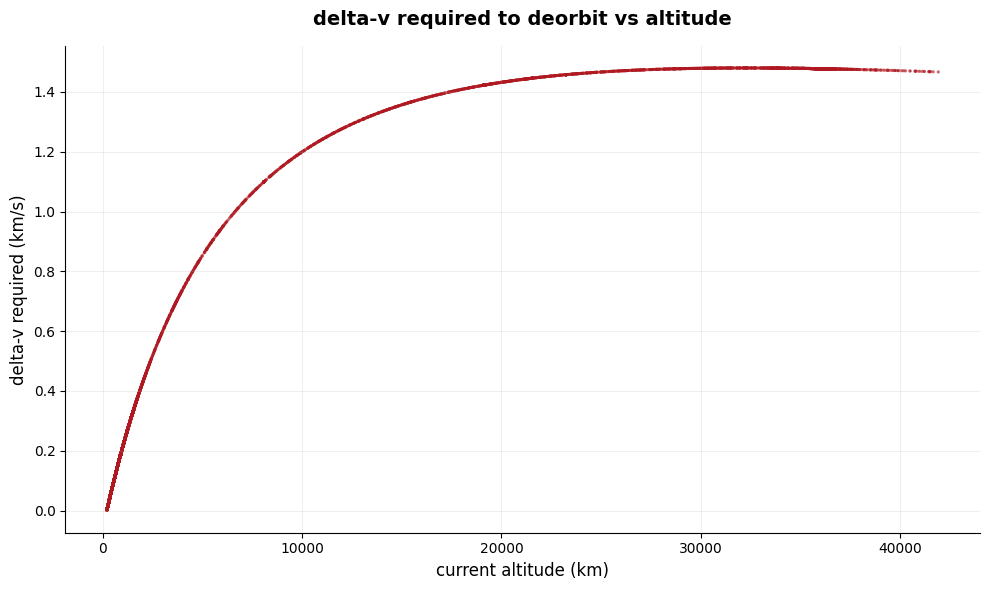

In [4]:
# delta-v vs altitude — should show a clear curve
fig, ax = plt.subplots(figsize=(10, 6))

sample = merged[merged['altitude_km'].between(200, 42000)].dropna(subset=['deltav_km_s'])

ax.scatter(sample['altitude_km'], sample['deltav_km_s'],
           c="#b01921", s=5, alpha=0.4, edgecolors='none')

ax.set_title('delta-v required to deorbit vs altitude', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('current altitude (km)', fontsize=12)
ax.set_ylabel('delta-v required (km/s)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2898/2914479435.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  regime_dv = merged.groupby('regime')['deltav_km_s'].median().reindex(['VLEO', 'LEO', 'MEO', 'GEO']).dropna()


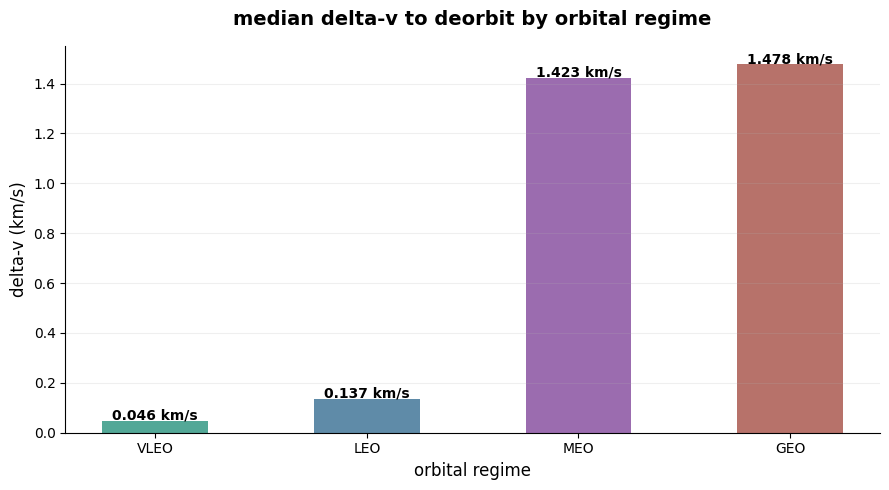

In [5]:
# delta-v by orbital regime — how hard is each regime to clean up
fig, ax = plt.subplots(figsize=(9, 5))

regime_dv = merged.groupby('regime')['deltav_km_s'].median().reindex(['VLEO', 'LEO', 'MEO', 'GEO']).dropna()
colors = ["#53a897", "#5f8ba8", "#9b6caf", "#b7726a"]

bars = ax.bar(regime_dv.index, regime_dv.values, color=colors, edgecolor='none', width=0.5)

for bar, val in zip(bars, regime_dv.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f} km/s', ha='center', fontweight='bold', fontsize=10)

ax.set_title('median delta-v to deorbit by orbital regime', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('orbital regime', fontsize=12)
ax.set_ylabel('delta-v (km/s)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

In [6]:
# most critical objects — high risk AND hard to deorbit
# these are the ones we should prioritize

merged['deorbit_priority'] = merged['deltav_km_s'] * merged['altitude_km'] / 1000

priority_list = merged[['OBJECT_NAME', 'OBJECT_TYPE', 'altitude_km', 
                          'deltav_km_s', 'risk_label']].dropna().sort_values('deltav_km_s', ascending=False)

print("top 15 hardest objects to deorbit:")
priority_list.head(15)

top 15 hardest objects to deorbit:


,OBJECT_NAME,OBJECT_TYPE,altitude_km,deltav_km_s,risk_label
44523,ATLAS 5 CENTAUR DEB,DEBRIS,32285.291883,1.4802,LOW
38800,CZ-3C DEB,DEBRIS,32257.238764,1.4802,MEDIUM
44520,ATLAS 5 CENTAUR DEB,DEBRIS,32216.414768,1.4802,LOW
25809,ARIANE 2 DEB,DEBRIS,32270.297383,1.4802,MEDIUM
38452,BREEZE-M R/B,ROCKET BODY,32132.561372,1.4802,LOW
26353,IUS R/B(1),ROCKET BODY,31989.067850,1.4802,HIGH
23798,ARIANE 44LP DEB,DEBRIS,32167.201796,1.4802,MEDIUM
42559,ATLAS 5 CENTAUR DEB,DEBRIS,32291.708801,1.4802,LOW
26817,TITAN 34D TRANSTAGE DEB,DEBRIS,31977.333859,1.4802,MEDIUM
18577,HIPPARCOS,PAYLOAD,32185.331584,1.4802,MEDIUM


In [7]:
merged.to_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/merged/ML_merged.parquet", index=False)
print("saved with delta-v!!", merged.shape)

saved with delta-v!! (66727, 57)
